# Poisonous Loan Approvals

Jeet Purohit
 Malek

In [1]:
# Calculation and plottings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

#XAI imports
import shap

# For Models
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.base import clone

# Metrics 
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve
    ) 


# Data preperation and Analysis

    Its better if an approved loan gets rejected by the model, then an rejected loan gets approved!
    kan vi ha någon stans

In [2]:
df = pd.read_csv("loan_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


    Feature distribution for some features.

In [3]:
features = [
    'person_gender', 'person_education',
    'person_home_ownership', 'loan_intent',
    'previous_loan_defaults_on_file', 'loan_status'
]

for col in features:
    print(f"\n {col}")
    counts = df[col].value_counts()
    total = counts.sum()
    for val, cnt in counts.items():
        pct = cnt / total * 100
        print(f"  {val}: {cnt} ({pct:.1f}%)")


 person_gender
  male: 24841 (55.2%)
  female: 20159 (44.8%)

 person_education
  Bachelor: 13399 (29.8%)
  Associate: 12028 (26.7%)
  High School: 11972 (26.6%)
  Master: 6980 (15.5%)
  Doctorate: 621 (1.4%)

 person_home_ownership
  RENT: 23443 (52.1%)
  MORTGAGE: 18489 (41.1%)
  OWN: 2951 (6.6%)
  OTHER: 117 (0.3%)

 loan_intent
  EDUCATION: 9153 (20.3%)
  MEDICAL: 8548 (19.0%)
  VENTURE: 7819 (17.4%)
  PERSONAL: 7552 (16.8%)
  DEBTCONSOLIDATION: 7145 (15.9%)
  HOMEIMPROVEMENT: 4783 (10.6%)

 previous_loan_defaults_on_file
  Yes: 22858 (50.8%)
  No: 22142 (49.2%)

 loan_status
  0: 35000 (77.8%)
  1: 10000 (22.2%)


# Data Preproccessing

    - Remove unnecessary features: Person_Gender
    - The income means for each gender are not far apart, but we think it is possible that the model could learn some bias from the data we have.
    - We change the categorical features to Numerical values. we give them an easy interval e.g. 0 lowest education, 4 masters education

In [4]:
mean_income_by_gender = df.groupby("person_gender")["person_income"].mean()
for gender, mean_income in mean_income_by_gender.items():
    print(f"{gender}: Mean income = {mean_income:.2f}")

female: Mean income = 79410.90
male: Mean income = 81056.03


In [5]:
df = df.drop(columns=["person_gender"])

In [6]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

Categorical columns: ['person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']



In [7]:
label_encoders = {}
df_numerical = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_numerical[col] = le.fit_transform(df_numerical[col])
    label_encoders[col] = le
    # print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded shape: {df_numerical.shape}")
df_numerical.iloc[13:20]


Encoded shape: (45000, 13)


,person_age,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
13,26.0,4,130713.0,0,3,35000.0,1,18.39,0.27,4.0,708,0,1
14,23.0,0,138998.0,0,3,35000.0,1,7.90,0.25,4.0,583,0,0
15,23.0,4,600891.0,5,0,30000.0,0,10.65,0.05,3.0,670,1,0
16,23.0,1,144943.0,0,3,35000.0,1,7.90,0.24,4.0,663,0,0
17,23.0,3,111369.0,0,3,35000.0,3,20.00,0.31,4.0,694,0,1
18,23.0,1,136628.0,0,3,35000.0,0,18.25,0.26,4.0,709,0,1
19,24.0,4,14283.0,1,0,1750.0,1,10.99,0.12,2.0,679,0,1


    - below cell shows the transformed features and their mapping

In [8]:
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} mapping:")
    for k, v in mapping.items():
        print(f"  {k}: {v}")
    print()

person_education mapping:
  Associate: 0
  Bachelor: 1
  Doctorate: 2
  High School: 3
  Master: 4

person_home_ownership mapping:
  MORTGAGE: 0
  OTHER: 1
  OWN: 2
  RENT: 3

loan_intent mapping:
  DEBTCONSOLIDATION: 0
  EDUCATION: 1
  HOMEIMPROVEMENT: 2
  MEDICAL: 3
  PERSONAL: 4
  VENTURE: 5

previous_loan_defaults_on_file mapping:
  No: 0
  Yes: 1



    - Feature dependencies and correlations
    
    - NOTE! high correlation between person_age, Person_employment_experiance and person_credit_history_length. We will later perform a test where we remove Person_age, this action results in other more important features influence the Isolation forest prediction

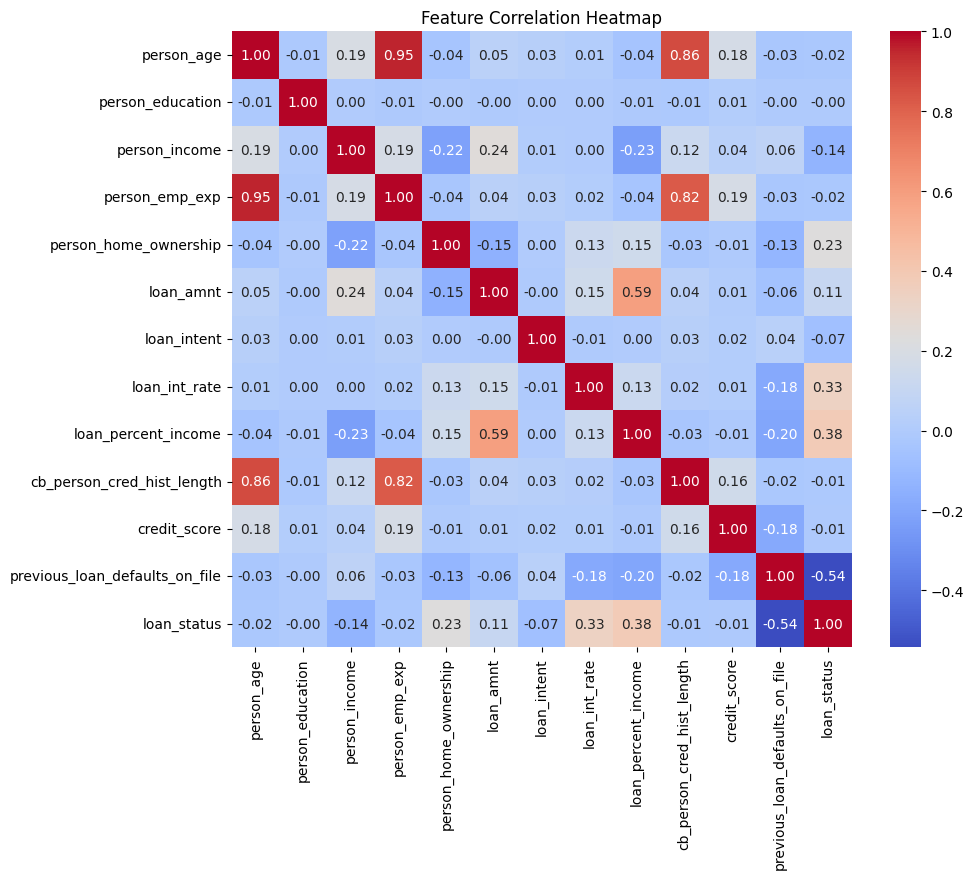

In [9]:
# Load dataset (change path or DataFrame if needed)
df = pd.read_csv('loan_data.csv')

# Compute correlation matrix
corr = df_numerical.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Missing values/incomplete samples

In [10]:
nulls = df_numerical.isnull().sum()
total_null = nulls.sum()
print("number of null", total_null)

number of null 0


# Outliers
    - We see that there are only 7 people over 100 taking loans. We remove these because they will not make much of a difference in the overall dataset, which has 35,000 samples.
    - 24 people have an income over 1 million.
    - 12 people have over 50 years of experience; its an rare sample.
    - We converted float to int in cb_person_cred_hist_length because we saw that there were no float values.

In [11]:
person_age_100 = (df_numerical['person_age'] >= 100).sum()
person_age_20 = (df_numerical['person_age'] < 20).sum()
print(f"Number of samples with person_age more then 100: {person_age_100}")
print(f"Number of samples with person_age less then 20: {person_age_20}")



Number of samples with person_age more then 100: 7
Number of samples with person_age less then 20: 0


In [12]:
person_income_1M = (df_numerical['person_income'] > 1000000).sum()
print(f"Number of samples with person_income > 1M: {person_income_1M}")

Number of samples with person_income > 1M: 24


In [13]:
person_emp_exp_over_ = (df_numerical['person_emp_exp'] > 50).sum()
print(f"Number of samples with person_emp_exp > 50: {person_emp_exp_over_}")

Number of samples with person_emp_exp > 50: 12


In [14]:
# Convert all values in cb_person_cred_hist_length to integers
df_numerical['cb_person_cred_hist_length'] = df_numerical['cb_person_cred_hist_length'].astype(int)

print(df_numerical['cb_person_cred_hist_length'].head())

0    3
1    2
2    3
3    2
4    4
Name: cb_person_cred_hist_length, dtype: int64


In [15]:
original_rows = df.shape[0]

# Remove people with loan_amount > 100
df = df[df['person_age'] <= 100]

# Remove people with income > 1000000
df = df[df['person_income'] <= 1000000]

# Remove people with experience > 50
df = df[df['person_emp_exp'] <= 50]


filtered_rows = df.shape[0]
rows_removed = original_rows - filtered_rows
print(f"Rows removed: {rows_removed}")

Rows removed: 33


# Data preprocessing 
    - splitting the data

In [16]:
X = df_numerical.drop(columns=["loan_status"])
y = df_numerical["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


# Evaulation and Model tuning
## Tuning

    - Use GridSearchCV to try all the combination in the param_grid.

    - In the first run, we had a lot of different combinations in param_grid; this took 4 minutes to run. In the second run, we narrowed the parameter values around the "best fit" parameters. For example, if we had max_depth 20 in the first run, we then changed the grid so that it checks the values: 18, 20, 23, 24, None. Each completed run we change the intervall to check for the best combination.

    - Commented cell is the First grid we used. it took 5 minutes to run. the cell below uses param_grid but with the best parameters already completed.

In [17]:
# param_grid = {
#     'max_depth': [16, 18, 25, None],
#     'min_samples_split': [7, 10, 12, 20,],
#     'min_samples_leaf': [29, 32, 35, 38],
#     'class_weight': ["balanced", None],
#     'min_weight_fraction_leaf' : [0.0, 0.05],
#     'max_features' : ['sqrt', 'log2', None]
# }


In [18]:

dt_model = DecisionTreeClassifier(random_state=42)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
dt_metrics = ['f1', 'precision', 'recall']

# Model tuning, finding best parameters --------------------------------------------
param_grid = {
    'max_depth': [18],
    'min_samples_split': [7],
    'min_samples_leaf': [35],
    'class_weight': [None],
    'min_weight_fraction_leaf' : [0.0],
    'max_features' : [None]
}

# !Note! change n_jobs in parameters below depending on how many cores you want to use.
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, 
                           cv=10, n_jobs=-1, verbose=2, scoring=dt_metrics, refit='f1') 

grid_search.fit(X_train, y_train)
tuned_dt = grid_search.best_estimator_ #here we set the best parameters on our model

best_params = grid_search.best_params_ 
print("\n")
print(f"Best parameters:\n ")
for param, value in best_params.items():
    print(f"{param}:  {value}")

#-----------------------------------------------------------------------------------------

# Evaluation across 10 folds with the fine tuned model -----------------------------------
cv_results = cross_validate(tuned_dt, X_train, y_train, cv=skf, scoring=dt_metrics,
                            return_train_score=False)

print("\n")
print("scores evaluation phase:\n")
for metric in dt_metrics:
    dt_test_scores = cv_results[f"test_{metric}"]
    print(f"{metric:>10s}:  mean={dt_test_scores.mean():.4f}  std={dt_test_scores.std():.4f}")

#-----------------------------------------------------------------------------------------
y_pred = tuned_dt.predict(X_test)

real_f1   = f1_score(y_test, y_pred)
real_prec = precision_score(y_test, y_pred)
real_rec  = recall_score(y_test, y_pred)

print("\n")
print(" Scores y_train vs y_test\n")

print(f"F1:        {real_f1:.4f}")
print(f"Precision: {real_prec:.4f}")
print(f"Recall:    {real_rec:.4f}")


Fitting 10 folds for each of 1 candidates, totalling 10 fits


Best parameters:
 
class_weight:  None
max_depth:  18
max_features:  None
min_samples_leaf:  35
min_samples_split:  7
min_weight_fraction_leaf:  0.0


scores evaluation phase:

        f1:  mean=0.8071  std=0.0115
 precision:  mean=0.8536  std=0.0132
    recall:  mean=0.7656  std=0.0153


 Scores y_train vs y_test

F1:        0.7999
Precision: 0.8399
Recall:    0.7635


# Test on unseen data
    - This test is made so we can see if our model performs similar to above. Not similar = overfitting or a problem in data splitting.

In [19]:
print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))


              precision    recall  f1-score   support

    Rejected       0.93      0.96      0.95      7000
    Approved       0.84      0.76      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.87      9000
weighted avg       0.91      0.92      0.91      9000



# Confusion metrics
    upper left → TN, upper right → FP
    lower left → FN, lower right → TP

    We want the FP to be as low as possible. We want the model to preferably reject loans that should not be approved.
    If FP is high, the model is more likely to approve loans that should be rejected.

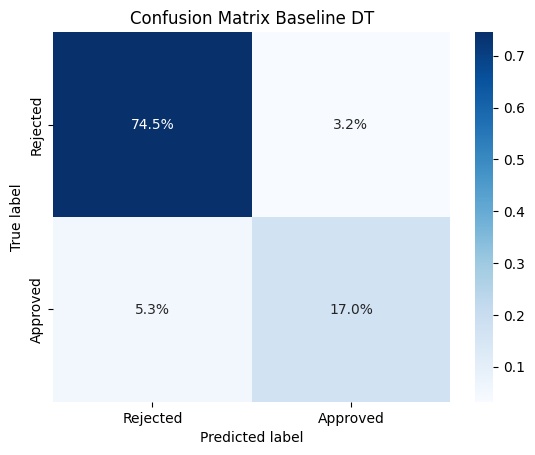

In [20]:

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum() * 100  # Convert to percent of all samples

cf_norm = cm.astype('float') / cm.sum()

# Create annotation text with '%'
labels = (np.asarray(["{0:.1f}%".format(value*100) 
                    for value in cf_norm.flatten()])).reshape(2,2)

sns.heatmap(cf_norm, annot=labels, fmt='', cmap='Blues', xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Baseline DT")
plt.show()

# Print tree

In [21]:
plt.figure(figsize=(250, 90))
plot_tree(tuned_dt, feature_names=X_train.columns, class_names=['Not Approved', 'Approved'], filled=True, max_depth=3)
plt.show()

# Feature importance
    shows us waht order the samples goes through to end up with a classification. 

Tree depth: 18
Number of leaves: 283

previous_loan_defaults_on_file    0.4102
loan_int_rate                     0.1814
loan_percent_income               0.1809
person_income                     0.1120
person_home_ownership             0.0542
loan_intent                       0.0272
credit_score                      0.0221
loan_amnt                         0.0067
person_age                        0.0020
person_education                  0.0013
cb_person_cred_hist_length        0.0012
person_emp_exp                    0.0010


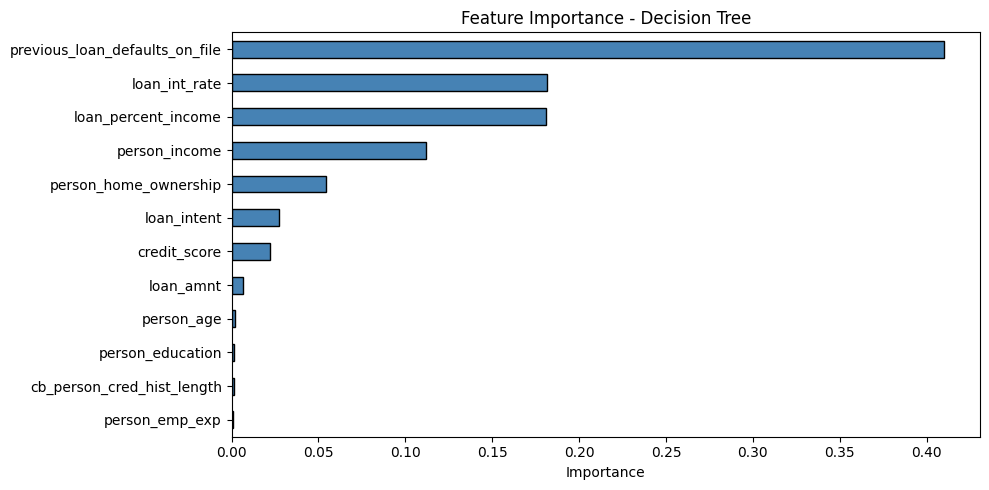

In [22]:
importances = pd.Series(tuned_dt.feature_importances_, index=X.columns).sort_values(ascending=False)

print(f"Tree depth: {tuned_dt.get_depth()}")
print(f"Number of leaves: {tuned_dt.get_n_leaves()}\n")
print(importances.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.barh(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Feature Importance - Decision Tree")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

    ROC curve that shows how well our model performs

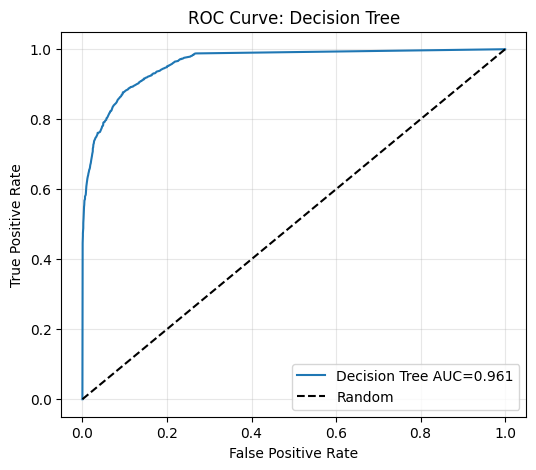

In [23]:

# Get predicted probabilities for the positive class (Approved = 1)
y_proba = tuned_dt.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Decision Tree AUC={auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

    Below is an analysis on the most important feature: "previous_loan_defaults_on_file"
    We see that there are NO samples where a samples has had a Default (not payed back previous lones) AND had their loans approved.

    This is the behaviour we want, we want more loans to be rejected then approved. its better that a loan gets a approved loan rejected then a rejected loan approved


In [24]:
# Create a cross-tabulation to see all combinations
combination_counts = pd.crosstab(
    df_numerical['previous_loan_defaults_on_file'],
    df_numerical['loan_status']
)

# Rename the index and columns for better readability
combination_counts.index = combination_counts.index.map({0: 'No Previous Default (0)', 1: 'Previous Default (1)'})
combination_counts.columns = combination_counts.columns.map({0: 'Loan Rejected (0)', 1: 'Loan Approved (1)'})


print("Breakdown of Loan Status vs. Previous Defaults:")
print(combination_counts)

Breakdown of Loan Status vs. Previous Defaults:
loan_status                     Loan Rejected (0)  Loan Approved (1)
previous_loan_defaults_on_file                                      
No Previous Default (0)                     12142              10000
Previous Default (1)                        22858                  0


# Data poisoning
    - We perform lable flipping attack on the Training dataset. 
    - The end % flipped lables are 25%

In [25]:
def label_flipping_attack(y_tr, flip_pct, seed=42):
    """Flip a percentage of training labels at random."""
    rng = np.random.RandomState(seed)
    y_poisoned = y_tr.copy()
    n_flip = int(len(y_tr) * flip_pct)
    flip_idx = rng.choice(y_tr.index, size=n_flip, replace=False)
    y_poisoned.loc[flip_idx] = 1 - y_poisoned.loc[flip_idx]
    return y_poisoned, flip_idx

In [26]:
flip_rates = [0.05, 0.10, 0.15, 0.20, 0.25]

flip_results = {}

for rate in flip_rates:
    y_poisoned, flipped = label_flipping_attack(y_train, rate)
    orig_counts = y_train.loc[flipped].value_counts().to_dict()

    dt_poison = clone(tuned_dt) # tuned_dt is the model with the best parametes from gridCV
    dt_poison.fit(X_train, y_poisoned)
    y_pred_poison = dt_poison.predict(X_test)

    poisoned_f1   = f1_score(y_test, y_pred_poison)
    poisoned_prec = precision_score(y_test, y_pred_poison)
    poisoned_rec  = recall_score(y_test, y_pred_poison)



    flip_results[rate] = {
        "n_flipped": len(flipped),
        "f1": round(poisoned_f1, 4),
        "precision": round(poisoned_prec, 4),
        "recall": round(poisoned_rec, 4),
        "cm": confusion_matrix(y_test, y_pred_poison),
    }

print(flipped) # index of the rows poisoned
print(f"Flip rate: {rate*100:.0f}%  ({len(flipped)} labels flipped)")
print(f"  F1       : {poisoned_f1:.4f}  (baseline {real_f1:.4f}, delta={poisoned_f1 - real_f1:+.4f})")
print(f"  Precision: {poisoned_prec:.4f} (baseline {real_prec:.4f}, delta={poisoned_prec - real_prec:+.4f})") 
print(f"  Recall   : {poisoned_rec:.4f} (baseline {real_rec:.4f}, delta={poisoned_prec - real_rec:+.4f})\n")

[21179  5660 17570 ... 36107 30219 43106]
Flip rate: 25%  (9000 labels flipped)
  F1       : 0.7143  (baseline 0.7999, delta=-0.0856)
  Precision: 0.7015 (baseline 0.8399, delta=-0.1384)
  Recall   : 0.7275 (baseline 0.7635, delta=-0.0620)



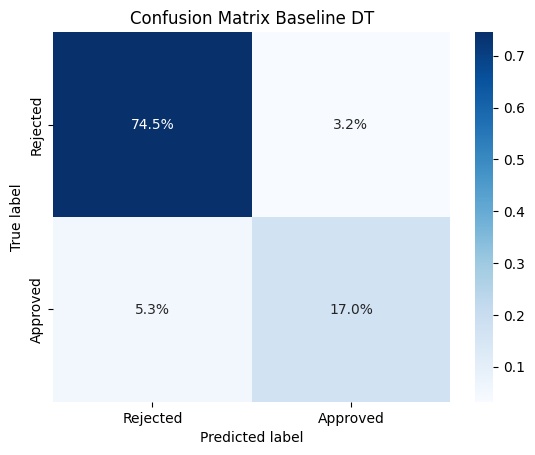

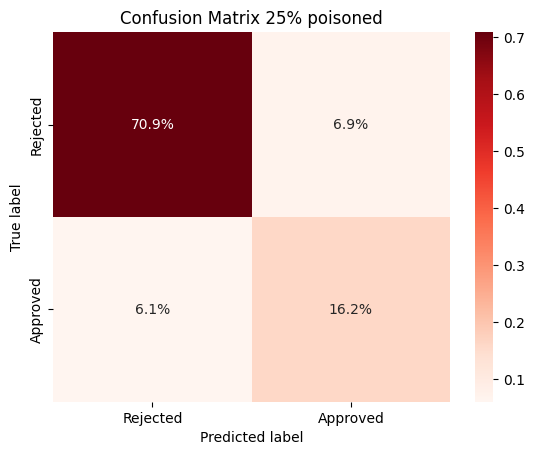

In [27]:
sns.heatmap(cf_norm, annot=labels, fmt='', cmap='Blues', xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Baseline DT")
plt.show()

#  confusion matrix for flip rate 25%
cm_poisoned = confusion_matrix(y_test, y_pred_poison)
cm_percent = cm_poisoned / cm_poisoned.sum() * 100  # Convert to percent of all samples

cf_norm_poisoned = cm_poisoned.astype('float') / cm_poisoned.sum()

# text with '%'
labels_poisoned = (np.asarray(["{0:.1f}%".format(value*100) 
                    for value in cf_norm_poisoned.flatten()])).reshape(2,2)

sns.heatmap(cf_norm_poisoned, annot=labels_poisoned, fmt='', cmap='Reds', xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix 25% poisoned")
plt.show()

# Rocauc after poisoned

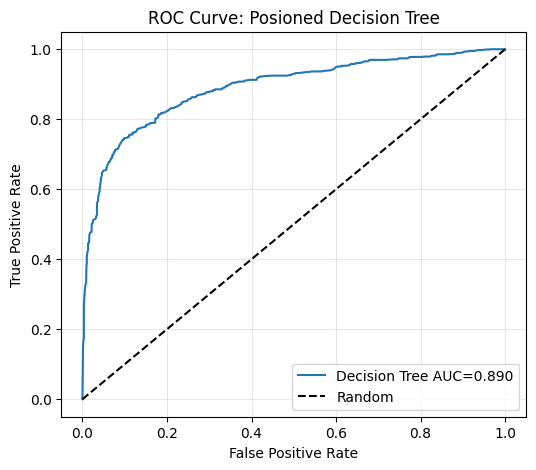

In [28]:
y_proba_poison = dt_poison.predict_proba(X_test)[:, 1]

# 2. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_poison)
auc = roc_auc_score(y_test, y_proba_poison)

# 3. Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Decision Tree AUC={auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Posioned Decision Tree")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

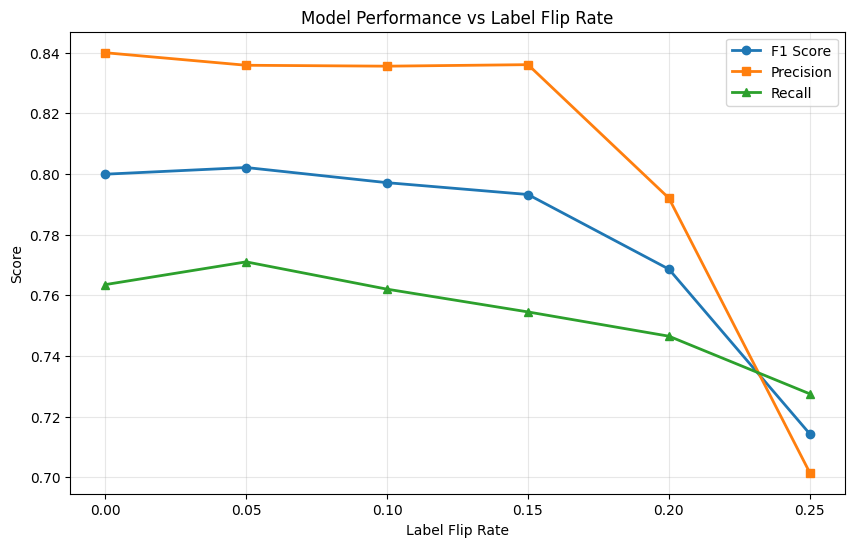

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
rates_with_baseline = [0] + flip_rates
f1_scores = [real_f1] + [flip_results[r]['f1'] for r in flip_rates]
prec_scores = [real_prec] + [flip_results[r]['precision'] for r in flip_rates]
rec_scores = [real_rec] + [flip_results[r]['recall'] for r in flip_rates]

ax.plot(rates_with_baseline, f1_scores, 'o-', label='F1 Score', linewidth=2)
ax.plot(rates_with_baseline, prec_scores, 's-', label='Precision', linewidth=2)
ax.plot(rates_with_baseline, rec_scores, '^-', label='Recall', linewidth=2)
ax.set_xlabel('Label Flip Rate')
ax.set_ylabel('Score')
ax.set_title('Model Performance vs Label Flip Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Isolation forest

    - Grid search wants scores, but Isolation Forest does not have scores due to being an unsupervised model. However, we can do it custom: we calculate the performance by checking how many anomalies, out of the true flipped anomalies, the Isolation Forest detects. With that, we have created our own search. It exhaustively searches all combinations and updates the "best score" variable.

    - We calculate the performance by checking how many anomalies, out of the true flipped anomalies, the Isolation Forest detects. With that, we have created our own search. It exhaustively searches all combinations and updates the "best score" variable.

    - We show the parameters we have used to get the best hyperparameters for our model (commented cell). We have extracted the best parameters from the cell below and added them in the uncommented cell for faster runtime.

In [30]:
# param_grid2 = {
#     'n_estimators': [150, 200, 250, 300],
#     'max_samples': [20, 30, 40, 50],
#     'contamination': [0.1, 0.15, 0.19, 0.25],
#     'bootstrap' : [False, True],
#     'max_features' : [3, 4, 5, 12]
# }

In [31]:
param_grid2 = {
    'n_estimators': [200],
    'max_samples': [30],
    'contamination': [0.19],
    'bootstrap' : [False],
    'max_features' : [4]
}

# Get all combinations of parameters
keys, values = zip(*param_grid2.items())
param_combinations = [dict(zip(keys, v)) for v in product(*values)]

best_score = -1
best_params = None
best_anomaly_indices = None
best_detected_poisoned = None

for params in param_combinations:
    iso_model = IsolationForest(**params, random_state=42)
    preds = iso_model.fit_predict(X_train)
    anomaly_indices = set(X_train.index[preds == -1])


    detected_poisoned = anomaly_indices & set(flipped)
    score = len(detected_poisoned)


    # Track the best score
    if score > best_score:
        best_score = score
        best_params = params
        best_anomaly_indices = anomaly_indices


iso_model_tuned = IsolationForest(**best_params, random_state=42)


print("total anomalies detected",len(best_anomaly_indices))
print("\nBest params:", best_params)
print("Max detected poisoned samples:", best_score)




total anomalies detected 6840

Best params: {'n_estimators': 200, 'max_samples': 30, 'contamination': 0.19, 'bootstrap': False, 'max_features': 4}
Max detected poisoned samples: 1738


# Fit the Isolation forest model

In [32]:
print(best_params)
iso_model_tuned.fit(X_train)

{'n_estimators': 200, 'max_samples': 30, 'contamination': 0.19, 'bootstrap': False, 'max_features': 4}


,n_estimators,200
,max_samples,30
,contamination,0.19
,max_features,4
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


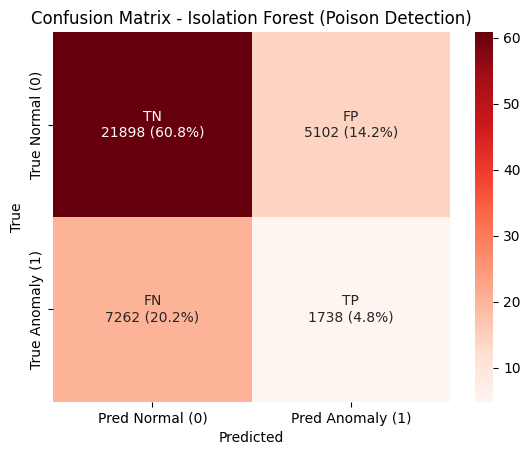

In [33]:
y_true_anom = X_train.index.isin(flipped).astype(int)

# Convert to binary so 1 = anomaly, 0 = normal
y_pred_anom = (iso_model_tuned.predict(X_train) == -1).astype(int)

# Confusion matrix with class order [0, 1]
cm_if = confusion_matrix(y_true_anom, y_pred_anom, labels=[0, 1])
tn, fp, fn, tp = cm_if.ravel()

total = cm_if.sum()

# Heatmap (percent of all samples)
cm_if_pct = cm_if / total * 100
labels_if = np.array([
    [f"TN\n{cm_if[0,0]} ({cm_if_pct[0,0]:.1f}%)", f"FP\n{cm_if[0,1]} ({cm_if_pct[0,1]:.1f}%)"],
    [f"FN\n{cm_if[1,0]} ({cm_if_pct[1,0]:.1f}%)", f"TP\n{cm_if[1,1]} ({cm_if_pct[1,1]:.1f}%)"]
])

sns.heatmap(
    cm_if_pct,
    annot=labels_if,
    fmt="",
    cmap="Reds",
    xticklabels=["Pred Normal (0)", "Pred Anomaly (1)"],
    yticklabels=["True Normal (0)", "True Anomaly (1)"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Isolation Forest (Poison Detection)")
plt.show()

# Confidence Isolation forest
    We do need to check if the 

Detected poisoned samples: 1738


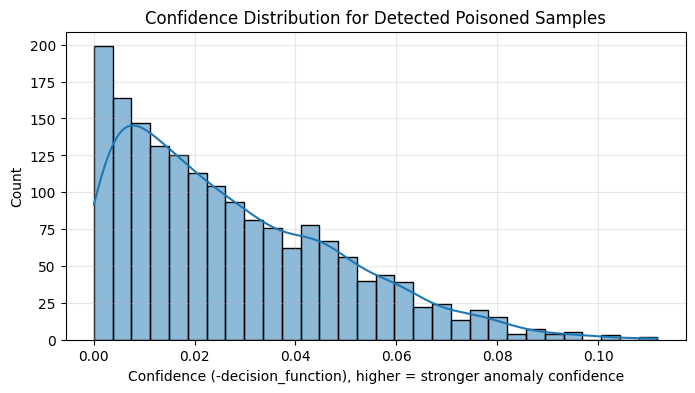

In [34]:
pred_if = iso_model_tuned.predict(X_train)  # -1 anomaly, 1 normal
pred_anom_idx = set(X_train.index[pred_if == -1])

flipped_idx = set(flipped)

detected_poisoned_idx = sorted(pred_anom_idx & flipped_idx)

print(f"Detected poisoned samples: {len(detected_poisoned_idx)}")

# Confidence on those detected poisoned samples
X_detected = X_train.loc[detected_poisoned_idx]
scores_detected = iso_model_tuned.decision_function(X_detected)   # lower = more anomalous
conf_detected = -scores_detected                                   # higher = more confident anomaly


plt.figure(figsize=(8,4))
sns.histplot(conf_detected, bins=30, kde=True)
plt.title("Confidence Distribution for Detected Poisoned Samples")
plt.xlabel("Confidence (-decision_function), higher = stronger anomaly confidence")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

# Show Precision Recall
    This shows the Precision and recall for the Isolation forest prediction between total anomalies and the flipped lables we had flipped.

    The results speaks for themself, its not very good.

In [35]:
raw = -iso_model_tuned.decision_function(X_train)
p5, p95 = np.percentile(raw, [5, 95])
conf01 = np.clip((raw - p5) / (p95 - p5 + 1e-12), 0, 1)
conf_band = np.where(conf01 >= 0.8, "strong", np.where(conf01 >= 0.5, "medium", "weak"))

y_true_poison = X_train.index.isin(flipped).astype(int)
y_pred_strong = (conf_band == "strong").astype(int)

cm = confusion_matrix(y_true_poison, y_pred_strong, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

precision_strong = tp / (tp + fp + 1e-12)
recall_strong = tp / (tp + fn + 1e-12)

print(f"Precision: {precision_strong:.4f}")
print(f"Recall: {recall_strong:.4f}")

Precision: 0.2565
Recall: 0.1102


# Evaluation with rocauc
    The ROC curve strengthen the precision and recall results. We se that its totaly random if a flipp lable sample is caught as a anomaly by the isolation forest

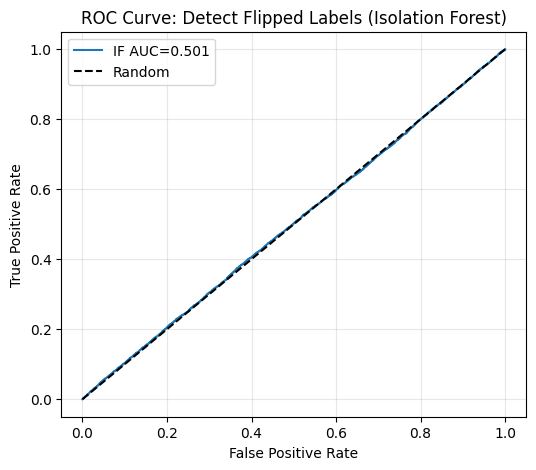

In [36]:


# Ground truth: 1 for poisoned (flipped), 0 for normal
y_true_anom = X_train.index.isin(flipped).astype(int)

anomaly_score = iso_model_tuned.decision_function(X_train)

fpr, tpr, _ = roc_curve(y_true_anom, -anomaly_score)  
auc = roc_auc_score(y_true_anom, -anomaly_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"IF AUC={auc:.3f}")
plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Detect Flipped Labels (Isolation Forest)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Checking path lenght
    - Isolation Forest outputs a score that is derived from the expected path length of each test instance, E(h(x)).
    - We check the expected path length and compare it to an anomaly's path length; this gives us a picture of how close each anomaly is to non-anomalies.

    - A more negative score correlates with a higher likelihood of being an anomaly.

    Results:
    If E(h(x)) > 0, then normal
    If E(h(x)) < 0, then anomaly


    

In [73]:
iso_predictions = iso_model_tuned.predict(X_train)
iso_scores = iso_model_tuned.decision_function(X_train)


anomalies = np.where(iso_predictions == -1)
normals = np.where(iso_predictions == 1)

# change number in the second position to change samples
anomaly_index = anomalies[0][2]
normal_index = normals[0][0]

# Get the score for the anomalous sample
anomaly_score = iso_scores[anomaly_index]

# Get the score for the normal sample
normal_score = iso_scores[normal_index]


    Minimum and maximum scores in the list of anomalies show that most predictions are close to 0, and that a score close to 0 is not necessarily a bad score.

In [38]:
print(iso_scores.min())
print(iso_scores.max())


-0.117265371201977
0.09339700027286785


# SHAP
    understanding the feature contribution of the samples that were predicted as anomaly or normal.

    we notice that isolation forest and decision tree DO NOT have the same importance in features.

Row position: 10
Prediction: ANOMALY (-1)
Decision score f(x): -0.0075


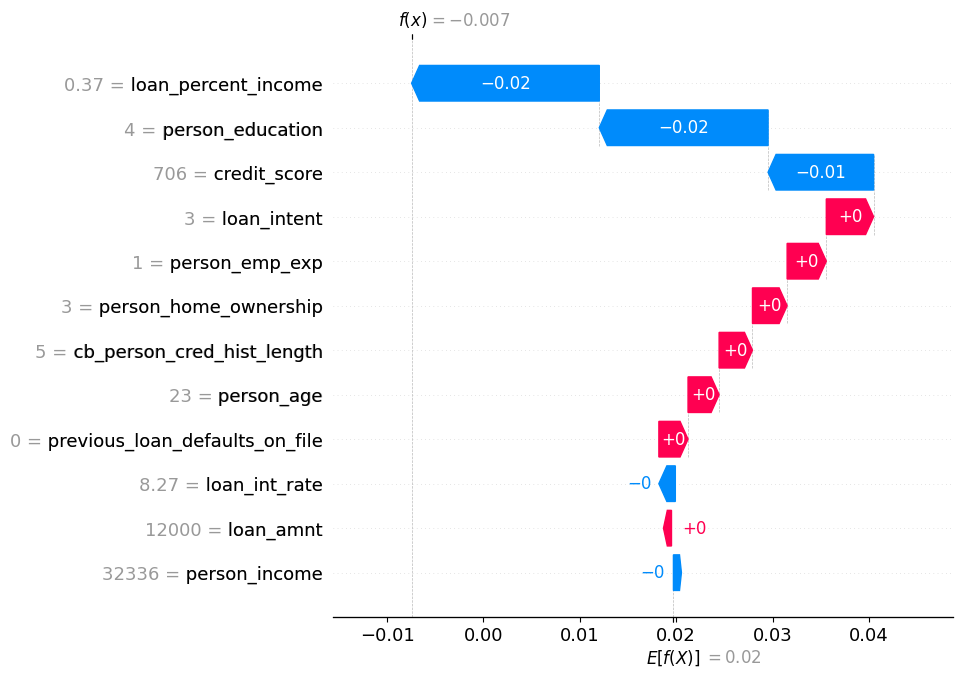

Row position: 0
Prediction: NORMAL (1)
Decision score f(x): 0.0205


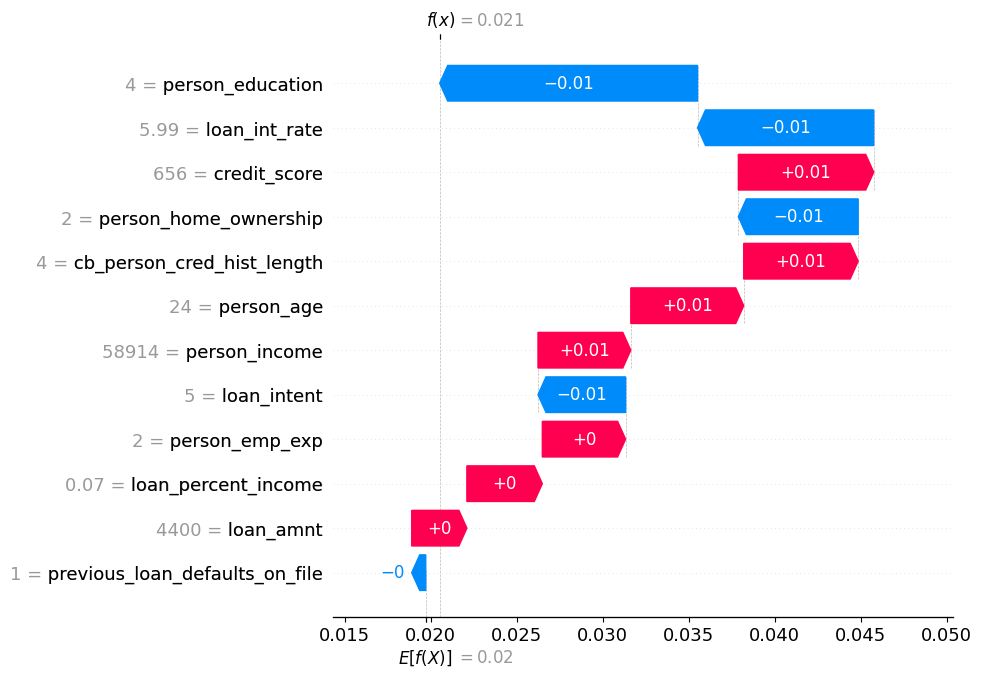

In [74]:
explainer_iso = shap.Explainer(iso_model_tuned.decision_function, X_train)

# creating new dataset for only the two samples
two_samples = X_train.iloc[[anomaly_index, normal_index]]

# get class labels (-1/1) and true scores ([1,-1]) for those exact rows.
pred_two = iso_model_tuned.predict(two_samples)
score_two = iso_model_tuned.decision_function(two_samples)

# SHAP values for same rows
shap_two = explainer_iso(two_samples)


label_map = {-1: "ANOMALY", 1: "NORMAL"}

for i, idx in enumerate([anomaly_index, normal_index]):
    print(f"Row position: {idx}")
    print(f"Prediction: {label_map[pred_two[i]]} ({pred_two[i]})")
    print(f"Decision score f(x): {score_two[i]:.4f}")

    shap.plots.waterfall(shap_two[i], max_display=12)

# Removing person_age
    Removing person_age, which had a high correlation with person_emp_exp and cb_person_cred_hist_length, changed how the Isolation Forest predicted decision scores. 
    
    Features that are more meaningful in a real-world setting moved higher in the feature impact ranking. For a normal sample, person_age affected the SHAP value more than person_income. 

    After removing person_age from the dataset, person_income contributed more than person_home_ownership, moving up two places in the contribution ranking.



Row position: 10
Prediction: ANOMALY (-1)
Decision score f(x): -0.0072


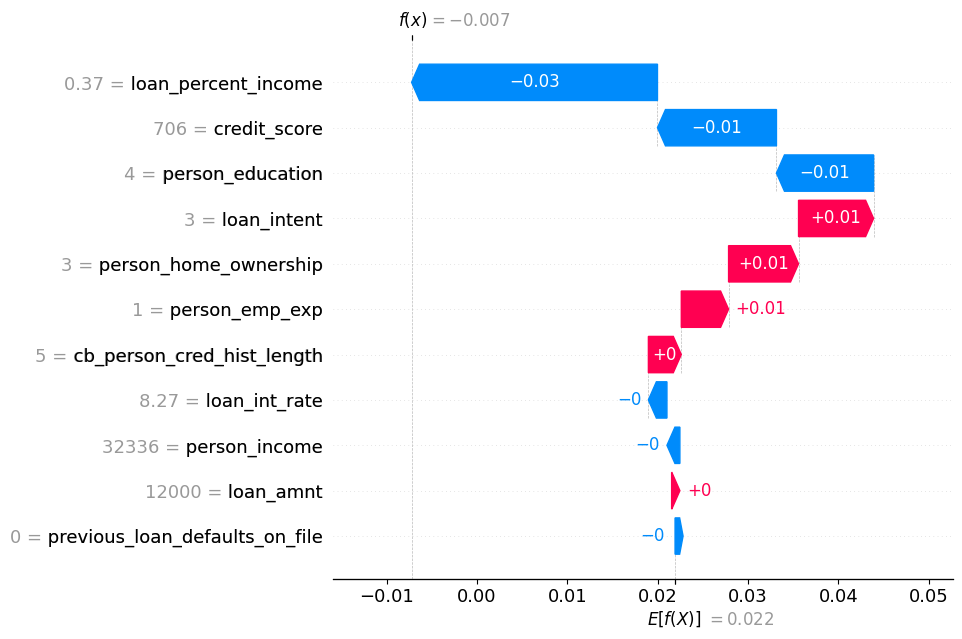

Row position: 0
Prediction: NORMAL (1)
Decision score f(x): 0.0174


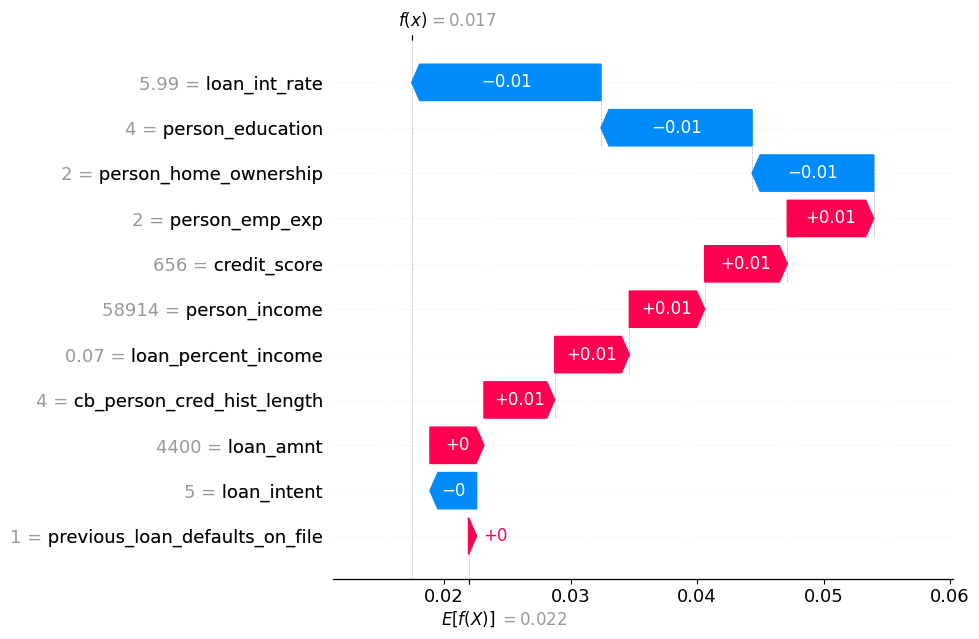

In [75]:
#removing person age and se if we get a change

# Local branch: remove person_age only here (no changes to df_numerical upstream)
X_train_no_age = X_train.drop(columns=["person_age"]).copy()
X_test_no_age = X_test.drop(columns=["person_age"]).copy()

# Train a separate IF model on no-age features
iso_model_no_age = IsolationForest(**best_params, random_state=42)
iso_model_no_age.fit(X_train_no_age)

# If you want to keep the same row positions as before:
idx_anom = 10
idx_norm = 0

two_samples_no_age = X_train_no_age.iloc[[idx_anom, idx_norm]]

pred_two = iso_model_no_age.predict(two_samples_no_age) 
score_two = iso_model_no_age.decision_function(two_samples_no_age)

explainer_no_age = shap.Explainer(iso_model_no_age.decision_function, X_train_no_age)
shap_two_no_age = explainer_no_age(two_samples_no_age)

label_map = {-1: "ANOMALY", 1: "NORMAL"}
for i, idx in enumerate([idx_anom, idx_norm]):
    print(f"Row position: {idx}")
    print(f"Prediction: {label_map[pred_two[i]]} ({pred_two[i]})")
    print(f"Decision score f(x): {score_two[i]:.4f}")
    shap.plots.waterfall(shap_two_no_age[i], max_display=12)

    below is if you want to choose a data row in the original CSV file loan_data.
    
    we wanted to examine if a higher education degree results in higher feature impact on the score. yes the higher education the more Isolation forest thinks its an anomaly.
    If we choose a samples that has an masters degree and 0 employment experiance, the model would get more negativly impacted.

csv_index: 2600
prediction: NORMAL (1)
decision score f(x): 0.0353


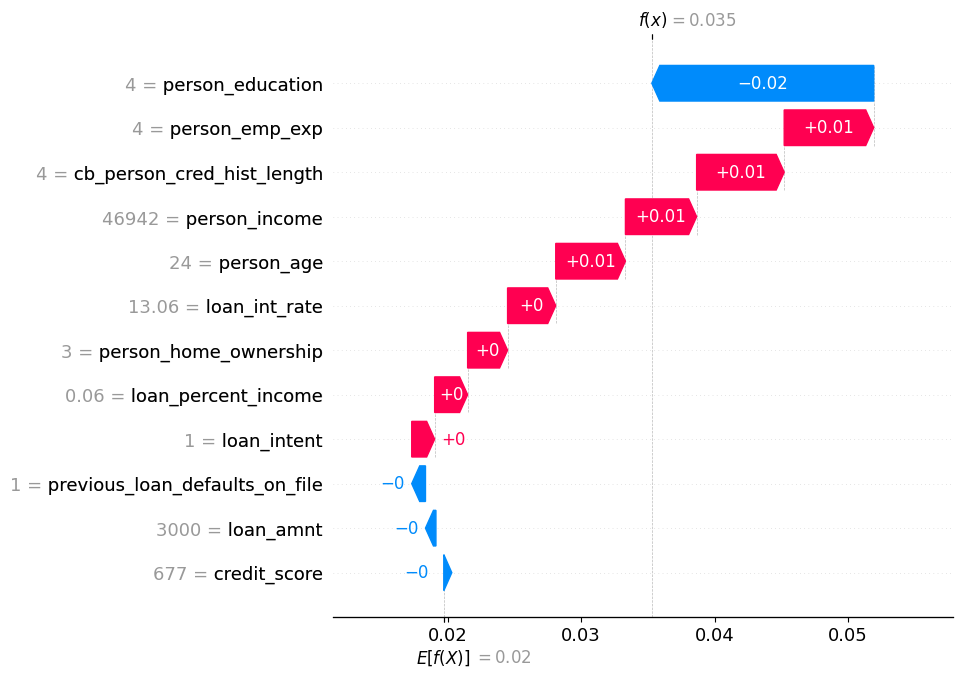

In [41]:
# Waterfall plot for the chosen sample

# diff in index pandas vs real -2
csv_index = 2602 - 2

pos_in_train = X_train.index.get_loc(csv_index)

chosen_sample = X_train.loc[[csv_index]]

chosen_pred = iso_model_tuned.predict(chosen_sample)[0]
chosen_score = iso_model_tuned.decision_function(chosen_sample)[0]
shap_chosen = explainer_iso(chosen_sample)
label = "ANOMALY" if chosen_pred == -1 else "NORMAL"
print(f"csv_index: {csv_index}")
print(f"prediction: {label} ({chosen_pred})")
print(f"decision score f(x): {chosen_score:.4f}")
shap.plots.waterfall(shap_chosen[0], max_display=12)

# Beeswarm plot
    checking how the features of 100 samples are distrubuted.

PermutationExplainer explainer: 101it [00:46,  1.71it/s]                         


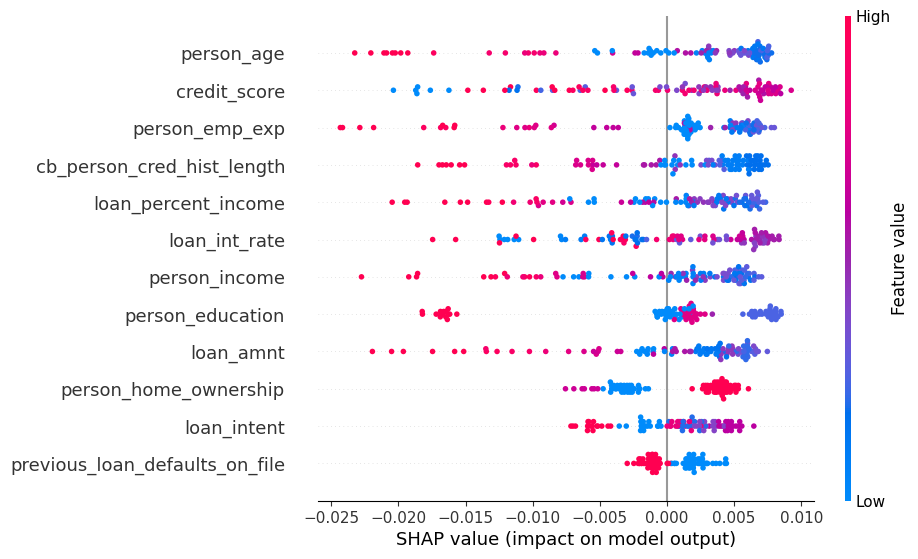

In [42]:
pred_all = iso_model_tuned.predict(X_train)
score_all = iso_model_tuned.decision_function(X_train)

# change first parameter (100) to increase or decrease samples
X_swarm = X_train.sample(n=min(100, len(X_train)), random_state=42)

shap_swarm = explainer_iso(X_swarm)
shap.plots.beeswarm(shap_swarm, max_display=12)



# Obeservation of Isolation forest and SHAP

    What does Isolation Forest classify, and what does SHAP explain?
    It is very important to understand the model being used. SHAP explains how the model reached its conclusion.
    Our goal was for Isolation Forest to find the attacked samples, but it identified the overall anomalies in our dataset.